In [7]:
import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.layers import InputLayer,Conv2D,MaxPooling2D,Flatten,Dense
from tensorflow.keras import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from keras.layers import Layer
from keras.layers import Reshape
from keras.layers import Lambda
from keras import initializers
import keras
from tensorflow.keras import backend as K
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model

## Preprocessing

In [9]:
def preprocessing(path):
    img = Image.open(path)
    img_resized = img.resize((224,224))
    return np.array(img_resized)/255

In [11]:
data_path = '../data/spectrograms/'
class0 = 'class_0'
class1 = 'class_1'
non_seizure = []
seizure = []
n_seizure_names = [f for f in os.listdir(os.path.join(data_path,class0))]
seizure_names = [f for f in os.listdir(os.path.join(data_path,class1))]

for path in n_seizure_names:
    non_seizure.append(preprocessing(os.path.join(data_path,class0,path)))
for path in seizure_names:
    seizure.append(preprocessing(os.path.join(data_path,class1,path)))

non_seizure_labels = [0]*len(non_seizure)
seizure_labels = [1]*len(seizure)
data = non_seizure+seizure
data_labels = non_seizure_labels+seizure_labels

X, y = shuffle(np.array(data), np.eye(2)[data_labels], random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size=1/3, random_state=42)

In [12]:
X.shape

(400, 224, 224, 4)

## Applying SMOTE

In [ ]:
X_flat = X_train.reshape((X_train.shape[0], -1))
smote=SMOTE(sampling_strategy='minority') 
X_train_resampled,y_train_resampled = smote.fit_resample(X_flat,y_train)
X_train = X_train_resampled.reshape((-1, 224, 224, 4))
y_train = np.eye(2)[y_train_resampled]

In [ ]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

## Model Functions

In [13]:
def squash(inputs):
    squared_norm = K.sum(K.square(inputs), axis=-1, keepdims=True)
    return (squared_norm / (1 + squared_norm)) / (K.sqrt(squared_norm + K.epsilon())) * inputs

class PrimaryCapsuleLayer(Layer):
    def __init__(self, num_capsules, capsule_dim, **kwargs):
        super(PrimaryCapsuleLayer, self).__init__(**kwargs)
        self.num_capsules = num_capsules
        self.capsule_dim = capsule_dim
        
    def build(self, input_shape):
        super(PrimaryCapsuleLayer, self).build(input_shape)
        
    def call(self, inputs):
        batch_size = K.shape(inputs)[0]
        reshaped = K.reshape(inputs, (batch_size, self.num_capsules, self.capsule_dim))
        return squash(reshaped)
    
    def compute_output_shape(self, input_shape):
        return (None, self.num_capsules, self.capsule_dim)

class DigitCapsuleLayer(Layer):
    def __init__(self, num_classes=2, capsule_dim=16, routings=3, **kwargs):
        super(DigitCapsuleLayer, self).__init__(**kwargs)
        self.num_classes = num_classes
        self.capsule_dim = capsule_dim
        self.routings = routings
        self.kernel_initializer = initializers.get('glorot_uniform')
    
    def build(self, input_shape):
        self.num_primary_capsules = int(input_shape[1])
        self.primary_capsule_dim = int(input_shape[2])
        
        self.W = self.add_weight(
            shape=(1, self.num_primary_capsules, self.num_classes, self.primary_capsule_dim, self.capsule_dim),
            initializer=self.kernel_initializer,
            name='weights'
        )
        self.built = True
    
    def call(self, inputs):
        batch_size = K.shape(inputs)[0]
        
        W_tiled = K.tile(self.W, [batch_size, 1, 1, 1, 1])
        
        inputs_expanded = K.expand_dims(K.expand_dims(inputs, 2), -1)
        inputs_tiled = K.tile(inputs_expanded, [1, 1, self.num_classes, 1, 1])
        
        # Matrix multiplication: (batch_size, num_primary_capsules, num_classes, capsule_dim)
        u_hat = K.sum(inputs_tiled * W_tiled, axis=3)
        
        b = tf.zeros(shape=[batch_size, self.num_primary_capsules, self.num_classes])
        
        for i in range(self.routings):
            c = K.softmax(b, axis=-1)  # (batch_size, num_primary_capsules, num_classes)
            
            c_expanded = K.expand_dims(c, -1)  # (batch_size, num_primary_capsules, num_classes, 1)
            s = K.sum(c_expanded * u_hat, axis=1)  # Sum over primary capsules
            
            # Squash to get output capsules
            v = squash(s)  # (batch_size, num_classes, capsule_dim)
            
            # Update routing coefficients (except for last iteration)
            if i < self.routings - 1:
                v_expanded = K.expand_dims(v, 1)
                agreement = K.sum(u_hat * v_expanded, axis=-1)
                b = b + agreement
        
        return v
    
    def compute_output_shape(self, input_shape):
        return (None, self.num_classes, self.capsule_dim)

def output_layer(inputs):
    return K.sqrt(K.sum(K.square(inputs), -1) + K.epsilon())

def mask(outputs):
    if type(outputs) != list:
        norm_outputs = K.sqrt(K.sum(K.square(outputs), -1) + K.epsilon())
        y = K.one_hot(indices=K.argmax(norm_outputs, 1), num_classes=2)
        y = K.expand_dims(y, -1)  # (batch_size, num_classes, 1)
        return Flatten()(y * outputs)
    else:
        y = K.expand_dims(outputs[1], -1)  # (batch_size, num_classes, 1)
        masked_output = y * outputs[0]
        return Flatten()(masked_output)

def loss_fn(y_true, y_pred):
    L = y_true * K.square(K.maximum(0., 0.9 - y_pred)) + \
        0.5 * (1 - y_true) * K.square(K.maximum(0., y_pred - 0.1))
    return K.mean(K.sum(L, 1))

In [14]:
# input_tensor = Input(shape=(224, 224, 4))

# conv1 = Conv2D(256, (9, 9), activation='relu', padding='valid')(input_tensor)
# conv2 = Conv2D(256, (9, 9), strides=2, activation='relu', padding='valid')(conv1)

# conv2_reshaped = Conv2D(256, (9, 9), strides=2, activation='relu', padding='valid')(conv2)

# primary_capsules_dim = 8
# num_primary_capsules = (48 * 48 * 256) // primary_capsules_dim

# primary_caps = PrimaryCapsuleLayer(
#     num_capsules=num_primary_capsules, 
#     capsule_dim=primary_capsules_dim
# )(Flatten()(conv2_reshaped))

# # Digit capsules
# digit_caps = DigitCapsuleLayer(num_classes=2, capsule_dim=16, routings=3)(primary_caps)

# # Output layer
# outputs = Lambda(output_layer)(digit_caps)

# # Masking for decoder
# inputs_label = Input(shape=(2,))
# masked = Lambda(mask)([digit_caps, inputs_label])
# masked_for_test = Lambda(mask)(digit_caps)

# # Decoder
# decoded_inputs = Input(shape=(2 * 16,))  # 2 classes * 16 dim
# dense1 = Dense(512, activation='relu')(decoded_inputs)
# dense2 = Dense(1024, activation='relu')(dense1)
# decoded_outputs = Dense(224 * 224 * 4, activation='sigmoid')(dense2)
# decoded_outputs = Reshape((224, 224, 4))(decoded_outputs)

# decoder = Model(decoded_inputs, decoded_outputs)

# # Final models
# model = Model([input_tensor, inputs_label], [outputs, decoder(masked)])
# test_model = Model(input_tensor, [outputs, decoder(masked_for_test)])

# print("Model created successfully!")
# print(f"Model input shape: {model.input_shape}")
# print(f"Model output shape: {model.output_shape}")

In [15]:
# # Compile model
# model.compile(
#     optimizer=keras.optimizers.Adam(learning_rate=0.001),
#     loss=[loss_fn, 'mse'],
#     loss_weights=[1., 0.0005],
#     metrics=['accuracy' , None]
# )

In [16]:
# # Callbacks
# early_stopping = EarlyStopping(
#     monitor='val_loss',
#     patience=5,
#     restore_best_weights=True
# )

# checkpoint = ModelCheckpoint(
#     '/Users/harshitpuralkar/Desktop/Projects/DL Project/MED_RES/weights/CapsuleNet.weights.h5',
#     monitor='val_loss',
#     save_best_only=True,
#     save_weights_only=True
# )

In [23]:
# # Train the model
# history = model.fit(
#     [X_train, y_train],  
#     [y_train, X_train],  
#     validation_data=([X_val, y_val], [y_val, X_val]),
#     epochs=30,
#     batch_size=20,
#     callbacks=[early_stopping, checkpoint]
# )

## Model Optimization

In [25]:
import gc
import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Reshape, Lambda
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.backend import clear_session
from hyperopt import STATUS_OK, STATUS_FAIL
import hyperopt
from hyperopt import tpe, hp, fmin, Trials

In [27]:
def objective(params):
    try:
        import gc
        K.clear_session()
        gc.collect()

        input_tensor = Input(shape=(224, 224, 4))

        conv1 = Conv2D(params['conv1s'], (params['conv1k'], params['conv1k']), activation='relu', padding='same')(input_tensor)
        conv2 = Conv2D(params['conv2s'], (params['conv2k'], params['conv2k']), strides=params['conv2str'], activation='relu', padding='same')(conv1)
        conv2_reshaped = Conv2D(params['convrs'], (params['convrk'], params['convrk']), strides=2, activation='relu', padding='same')(conv2)
        conv2_reshaped = MaxPooling2D(pool_size=(2, 2))(conv2_reshaped)

        conv_flatten = Flatten()(conv2_reshaped)

        primary_capsules_dim = params['capsuel_dim']
        h, w, c = int(conv2_reshaped.shape[1]), int(conv2_reshaped.shape[2]), int(conv2_reshaped.shape[3])
        num_primary_capsules = (h * w * c) // primary_capsules_dim

        primary_caps = PrimaryCapsuleLayer(num_capsules=num_primary_capsules, capsule_dim=primary_capsules_dim)(conv_flatten)
        digit_caps = DigitCapsuleLayer(num_classes=2, capsule_dim=params['dig_caps'], routings=3)(primary_caps)
        outputs = Lambda(output_layer)(digit_caps)

        inputs_label = Input(shape=(2,))
        masked = Lambda(mask)([digit_caps, inputs_label])
        masked_for_test = Lambda(mask)(digit_caps)

        decoded_inputs = Input(shape=(2 * params['dig_caps'],))
        dense1 = Dense(params['dense1'], activation='relu')(decoded_inputs)
        dense2 = Dense(params['dense2'], activation='relu')(dense1)
        decoded_outputs = Dense(224 * 224 * 4, activation='sigmoid')(dense2)
        decoded_outputs = Reshape((224, 224, 4))(decoded_outputs)

        decoder = Model(decoded_inputs, decoded_outputs)

        model = Model([input_tensor, inputs_label], [outputs, decoder(masked)])
        test_model = Model(input_tensor, [outputs, decoder(masked_for_test)])

        model.compile(
            optimizer=Adam(learning_rate=params['lr']),
            loss=[loss_fn, 'mse'],
            loss_weights=[1., 0.0005],
            metrics=['accuracy', None]
        )

        early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

        history = model.fit(
            [X_train, y_train],
            [y_train, X_train],
            validation_data=([X_val, y_val], [y_val, X_val]),
            epochs=30,
            batch_size=8,
            callbacks=[early_stopping],
            verbose=0
        )

        val_loss = min(history.history['val_loss'])

        # Clean-up
        del model
        gc.collect()
        K.clear_session()

        return {'loss': val_loss, 'status': STATUS_OK}

    except tf.errors.ResourceExhaustedError as e:
        print("OOM error, skipping trial.")
        return {'loss': float('inf'), 'status': STATUS_FAIL}
    except Exception as e:
        print("Other error:", e)
        return {'loss': float('inf'), 'status': STATUS_FAIL}

In [29]:
space = {
    'conv1s': hp.choice('conv1s', [64, 128, 256, 512]),
    'conv1k': hp.choice('conv1k', [3, 5, 7, 9, 11]),
    'conv2s': hp.choice('conv2s', [64, 128,256, 512]),
    'conv2k': hp.choice('conv2k', [3, 5, 7, 9, 11]),
    'conv2str': hp.choice('conv2str', [1, 2, 3]),
    'convrs': hp.choice('convrs', [64, 128, 256, 512]),
    'convrk': hp.choice('convrk', [3, 5, 7, 9, 11]),
    'capsuel_dim': hp.choice('capsuel_dim', [8, 16]),
    'dig_caps': hp.choice('dig_caps', [8, 16, 32]),
    'dense1': hp.choice('dense1', [256, 512, 1024]),
    'dense2': hp.choice('dense2', [512, 1024, 2048]),
    'lr': hp.loguniform('lr', np.log(1e-5), np.log(1e-3))
}

'''space = {
    'conv1s': hp.choice('conv1s', [64, 128, 256]),
    'conv1k': hp.choice('conv1k', [3, 5, 7, 9]),
    'conv2s': hp.choice('conv2s', [64, 128, 256]),
    'conv2k': hp.choice('conv2k', [3, 5, 7, 9]),
    'conv2str': hp.choice('conv2str', [1, 2]),
    'convrs': hp.choice('convrs', [64, 128, 256]),
    'convrk': hp.choice('convrk', [3, 5, 7, 9]),
    'capsuel_dim': hp.choice('capsuel_dim', [8, 16]),
    'dig_caps': hp.choice('dig_caps', [8, 16]),
    'dense1': hp.choice('dense1', [256, 512]),
    'dense2': hp.choice('dense2', [512, 1024]),
    'lr': hp.loguniform('lr', np.log(1e-5), np.log(1e-3))
}'''

## Saving Optimized Values

In [25]:
import pickle
from hyperopt import fmin, tpe, Trials
import os

TRIALS_FILE = "hyperopt_trials.pkl"
MAX_EVALS = 5

# Load existing trials if available
if os.path.exists(TRIALS_FILE):
    print("Loading existing trials...")
    with open(TRIALS_FILE, "rb") as f:
        trials = pickle.load(f)
    current_evals = len(trials.trials)
    print(f"Resuming from {current_evals} trials")
else:
    trials = Trials()
    current_evals = 0
    print("Starting new trials")

# Run optimization
best = fmin(
    fn=objective,
    space=space,
    algo=tpe.suggest,
    max_evals=MAX_EVALS,
    trials=trials
)

# Save updated trials
with open(TRIALS_FILE, "wb") as f:
    pickle.dump(trials, f)

print("Best hyperparameters:", best)


Starting new trials
100%|██████| 5/5 [5:50:27<00:00, 4205.49s/trial, best loss: 0.02030743472278118]
Best hyperparameters: {'capsuel_dim': np.int64(1), 'conv1k': np.int64(0), 'conv1s': np.int64(0), 'conv2k': np.int64(0), 'conv2s': np.int64(0), 'conv2str': np.int64(1), 'convrk': np.int64(0), 'convrs': np.int64(1), 'dense1': np.int64(0), 'dense2': np.int64(1), 'dig_caps': np.int64(1), 'lr': np.float64(0.0001636977664949298)}


In [31]:
'''values = {
    'conv1s': [64, 128, 256, 512],
    'conv1k': [3, 5, 7, 9, 11],
    'conv2s': [64, 128,256, 512],
    'conv2k': [3, 5, 7, 9, 11],
    'conv2str': [1, 2, 3],
    'convrs': [64, 128, 256, 512],
    'convrk': [3, 5, 7, 9, 11],
    'capsuel_dim': [8, 16],
    'dig_caps': [8, 16, 32],
    'dense1': [256, 512, 1024],
    'dense2': [512, 1024, 2048],
}'''

values = {
    'conv1s': [64, 128, 256],
    'conv1k': [3, 5, 7, 9],
    'conv2s': [64, 128,256],
    'conv2k': [3, 5, 7, 9],
    'conv2str': [1, 2],
    'convrs': [64, 128, 256],
    'convrk': [3, 5, 7, 9],
    'capsuel_dim': [8, 16],
    'dig_caps': [8, 16],
    'dense1': [256, 512],
    'dense2': [512, 1024],
}

In [33]:
best = {
    'capsuel_dim': np.int64(1),
    'conv1k': np.int64(0),
    'conv1s': np.int64(0),
    'conv2k': np.int64(0),
    'conv2s': np.int64(0),
    'conv2str': np.int64(1),
    'convrk': np.int64(0),
    'convrs': np.int64(1),
    'dense1': np.int64(0),
    'dense2': np.int64(1),
    'dig_caps': np.int64(1),
    'lr': np.float64(0.0001636977664949298)
}

In [35]:
print("Best hyperparameters:", best)

Best hyperparameters: {'capsuel_dim': np.int64(1), 'conv1k': np.int64(0), 'conv1s': np.int64(0), 'conv2k': np.int64(0), 'conv2s': np.int64(0), 'conv2str': np.int64(1), 'convrk': np.int64(0), 'convrs': np.int64(1), 'dense1': np.int64(0), 'dense2': np.int64(1), 'dig_caps': np.int64(1), 'lr': np.float64(0.0001636977664949298)}


In [37]:
optimized_values = {
    'conv1s': values['conv1s'][best['conv1s']],
    'conv1k': values['conv1k'][best['conv1k']],
    'conv2s': values['conv2s'][best['conv2s']],
    'conv2k': values['conv2k'][best['conv2k']],
    'conv2str': values['conv2str'][best['conv2str']],
    'convrs': values['convrs'][best['convrs']],
    'convrk': values['convrk'][best['convrk']],
    'capsuel_dim': values['capsuel_dim'][best['capsuel_dim']],
    'dig_caps': values['dig_caps'][best['dig_caps']],
    'dense1': values['dense1'][best['dense1']],
    'dense2': values['dense2'][best['dense2']],
    'lr': best['lr']
}

In [39]:
import json

# Convert the data to a JSON string
json_data = json.dumps(optimized_values, indent=2) 

# Write the JSON string to a file
with open('data.json', 'w') as file:
  file.write(json_data)

print("Data written to data.json")

Data written to data.json


## Model Creation

In [41]:
input_tensor = Input(shape=(224, 224, 4))

conv1 = Conv2D(optimized_values['conv1s'], (optimized_values['conv1k'], optimized_values['conv1k']), activation='relu', padding='same')(input_tensor)
conv2 = Conv2D(optimized_values['conv2s'], (optimized_values['conv2k'],optimized_values['conv2k']), strides=optimized_values['conv2str'], activation='relu', padding='same')(conv1)
conv2_reshaped = Conv2D(optimized_values['convrs'], (optimized_values['convrk'], optimized_values['convrk']), strides=2, activation='relu', padding='same')(conv2)
conv2_reshaped = MaxPooling2D(pool_size=(2, 2))(conv2_reshaped)

conv_flatten = Flatten()(conv2_reshaped)

primary_capsules_dim = optimized_values['capsuel_dim']
h, w, c = int(conv2_reshaped.shape[1]), int(conv2_reshaped.shape[2]), int(conv2_reshaped.shape[3])
num_primary_capsules = (h * w * c) // primary_capsules_dim

primary_caps = PrimaryCapsuleLayer(num_capsules=num_primary_capsules, capsule_dim=primary_capsules_dim)(conv_flatten)
digit_caps = DigitCapsuleLayer(num_classes=2, capsule_dim=optimized_values['dig_caps'], routings=3)(primary_caps)
outputs = Lambda(output_layer)(digit_caps)

inputs_label = Input(shape=(2,))
masked = Lambda(mask)([digit_caps, inputs_label])
masked_for_test = Lambda(mask)(digit_caps)

decoded_inputs = Input(shape=(2 * optimized_values['dig_caps'],))
dense1 = Dense(optimized_values['dense1'], activation='relu')(decoded_inputs)
dense2 = Dense(optimized_values['dense2'], activation='relu')(dense1)
decoded_outputs = Dense(128 * 128 * 4, activation='sigmoid')(dense2)
decoded_outputs = Reshape((128, 128, 4))(decoded_outputs)

decoder = Model(decoded_inputs, decoded_outputs)

model = Model([input_tensor, inputs_label], [outputs, decoder(masked)])
test_model = Model(input_tensor, [outputs, decoder(masked_for_test)])

model.compile(
    optimizer=Adam(learning_rate=optimized_values['lr']),
    loss=[loss_fn, 'mse'],
    loss_weights=[1., 0.0005],
    metrics=['accuracy', None]
)

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

checkpoint = ModelCheckpoint(
    '../weights/CapsuleNet.weights.h5',
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=True
)

In [61]:
input_tensor = Input(shape=(224, 224, 4))

conv1_filters = max(1, optimized_values['conv1s'])
conv1_kernel = max(1, optimized_values['conv1k'])
conv2_filters = max(1, optimized_values['conv2s'])
conv2_kernel = max(1, optimized_values['conv2k'])
conv2_stride = max(1, optimized_values['conv2str'])
convrs_filters = max(1, optimized_values['convrs'])
convrk_kernel = max(1, optimized_values['convrk'])
dense1_units = max(1, optimized_values['dense1'])
dense2_units = max(1, optimized_values['dense2'])

conv1 = Conv2D(conv1_filters, (conv1_kernel, conv1_kernel), activation='relu', padding='same')(input_tensor)
conv2 = Conv2D(conv2_filters, (conv2_kernel, conv2_kernel), strides=conv2_stride, activation='relu', padding='same')(conv1)
conv2_reshaped = Conv2D(convrs_filters, (convrk_kernel, convrk_kernel), strides=2, activation='relu', padding='same')(conv2)
conv2_reshaped = MaxPooling2D(pool_size=(2, 2))(conv2_reshaped)

conv_flatten = Flatten()(conv2_reshaped)

primary_capsules_dim = max(1, optimized_values['capsuel_dim'])
h, w, c = int(conv2_reshaped.shape[1]), int(conv2_reshaped.shape[2]), int(conv2_reshaped.shape[3])
num_primary_capsules = (h * w * c) // primary_capsules_dim

primary_caps = PrimaryCapsuleLayer(num_capsules=num_primary_capsules, capsule_dim=primary_capsules_dim)(conv_flatten)
digit_caps = DigitCapsuleLayer(num_classes=2, capsule_dim=optimized_values['dig_caps'], routings=3)(primary_caps)
outputs = Lambda(output_layer)(digit_caps)

inputs_label = Input(shape=(2,))
masked = Lambda(mask)([digit_caps, inputs_label])
masked_for_test = Lambda(mask)(digit_caps)

decoded_inputs = Input(shape=(2 * optimized_values['dig_caps'],))
dense1 = Dense(dense1_units, activation='relu')(decoded_inputs)
dense2 = Dense(dense2_units, activation='relu')(dense1)
decoded_outputs = Dense(128 * 128 * 4, activation='sigmoid')(dense2)
decoded_outputs = Reshape((128, 128, 4))(decoded_outputs)

decoder = Model(decoded_inputs, decoded_outputs)

model = Model([input_tensor, inputs_label], [outputs, decoder(masked)])
test_model = Model(input_tensor, [outputs, decoder(masked_for_test)])

model.compile(
    optimizer=Adam(learning_rate=optimized_values['lr']),
    loss=[loss_fn, 'mse'],
    loss_weights=[1., 0.0005],
    metrics=['accuracy', 'mse']
)

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

checkpoint = ModelCheckpoint(
    '../weights/CapsuleNet.weights.h5',
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=True
)


In [63]:
model.summary()
print(X_train.shape, y_train.shape)

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_9       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 224, 224,  │      2,368 │ input_layer_9[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 112, 112,  │     36,928 │ conv2d_9[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 56, 56,    │     73,856 │ conv2d_10[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 28, 28,    │          0 │ conv2d_11[0][0]   │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_14          │ (None, 100352)    │          0 │ max_pooling2d_3[… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ primary_capsule_la… │ (None, 6272, 16)  │          0 │ flatten_14[0][0]  │
│ (PrimaryCapsuleLay… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ digit_capsule_laye… │ (None, 2, 16)     │  3,211,264 │ primary_capsule_… │
│ (DigitCapsuleLayer) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_10      │ (None, 2)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_10 (Lambda)  │ (None, 32)        │          0 │ digit_capsule_la… │
│                     │                   │            │ input_layer_10[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_9 (Lambda)   │ (None, 2)         │          0 │ digit_capsule_la… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional_9        │ (None, 128, 128,  │ 67,446,016 │ lambda_10[0][0]   │
│ (Functional)        │ 4)                │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 70,770,432 (269.97 MB)

 Trainable params: 70,770,432 (269.97 MB)

 Non-trainable params: 0 (0.00 B)

(280, 224, 224, 4) (280, 2)


In [65]:
import tensorflow as tf

# Resize input for decoder target
X_train_resized = tf.image.resize(X_train, (128, 128))
X_val_resized = tf.image.resize(X_val, (128, 128))

# Training
history = model.fit(
  [X_train, y_train],
  [y_train, X_train_resized],
  validation_data=([X_val, y_val], [y_val, X_val_resized]),
  epochs=30,
  batch_size=8,
  callbacks=[early_stopping, checkpoint],
  verbose=1
)

val_loss = min(history.history['val_loss'])


Epoch 1/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 17s 452ms/step - functional_9_loss: 0.1227 - functional_9_mse: 0.1227 - lambda_9_accuracy: 0.7186 - lambda_9_loss: 0.3003 - loss: 0.3003 - val_functional_9_loss: 0.1211 - val_functional_9_mse: 0.1211 - val_lambda_9_accuracy: 0.7750 - val_lambda_9_loss: 0.1559 - val_loss: 0.1560
Epoch 2/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 15s 406ms/step - functional_9_loss: 0.1218 - functional_9_mse: 0.1218 - lambda_9_accuracy: 0.7531 - lambda_9_loss: 0.1542 - loss: 0.1543 - val_functional_9_loss: 0.1211 - val_functional_9_mse: 0.1211 - val_lambda_9_accuracy: 0.8250 - val_lambda_9_loss: 0.1494 - val_loss: 0.1495
Epoch 3/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 12s 344ms/step - functional_9_loss: 0.1225 - functional_9_mse: 0.1225 - lambda_9_accuracy: 0.8351 - lambda_9_loss: 0.1101 - loss: 0.1102 - val_functional_9_loss: 0.1211 - val_functional_9_mse: 0.1211 - val_lambda_9_accuracy: 0.8500 - val_lambda_9_loss: 0.0811 - val_loss: 0.0812
Epoch 4/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 12s 343ms/s

In [ ]:
# Training
history = model.fit(
  [X_train, y_train],
  [y_train, X_train],
  validation_data=([X_val, y_val], [y_val, X_val]),
  epochs=30,
  batch_size=8,
  callbacks=[early_stopping, checkpoint],
  verbose=0
)
val_loss = min(history.history['val_loss'])

In [69]:
print(history.history.keys())

dict_keys(['functional_9_loss', 'functional_9_mse', 'lambda_9_accuracy', 'lambda_9_loss', 'loss', 'val_functional_9_loss', 'val_functional_9_mse', 'val_lambda_9_accuracy', 'val_lambda_9_loss', 'val_loss'])


In [71]:
train_acc = history.history['lambda_9_accuracy']
val_acc = history.history['val_lambda_9_accuracy']

print(f"Final Training Accuracy: {train_acc[-1]:.4f}")
print(f"Final Validation Accuracy: {val_acc[-1]:.4f}")

Final Training Accuracy: 0.9964
Final Validation Accuracy: 1.0000


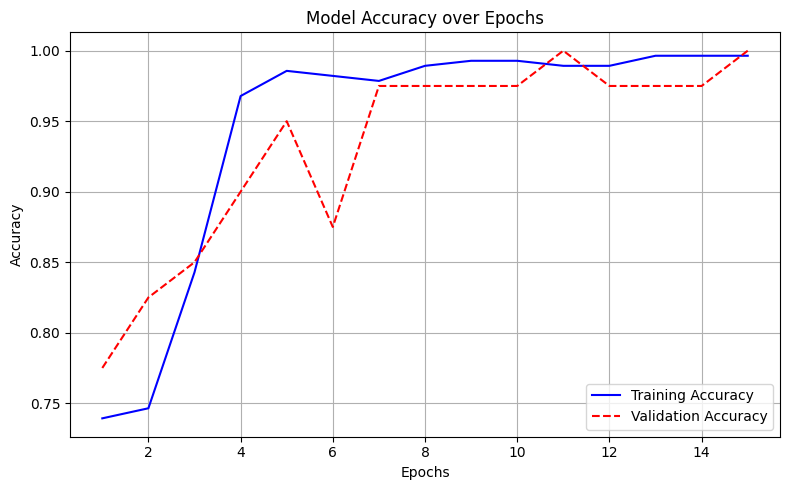

In [73]:
import matplotlib.pyplot as plt

train_acc = history.history['lambda_9_accuracy']
val_acc = history.history['val_lambda_9_accuracy']

epochs = range(1, len(train_acc) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_acc, 'b-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r--', label='Validation Accuracy')
plt.title('Model Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()